**Project:** PV configuration study for the 14-unit residential building at
Melli-Beese-Ring 1, Fliegerhorst Oldenburg (53.17295 N, 8.18185 E).
Groundbreaking 03/2026, completion planned 2027. As a new building with
>50 m² roof, §32a NBauO (Lower Saxony solar obligation) requires PV on
≥50% of the roof area — this study asks *which* configuration serves best.

**Method:** hourly simulation (pvlib / PVWatts model) over a Typical
Meteorological Year, comparing roof-south, roof-east-west, SE wing, and
WSW facade configurations on measured building geometry.

### Geometry sources
Roof areas measured in AutoCAD from site plan P01 (team 3 architekturbüro,
03.12.2024, M 1:500), calibrated against the instructor-provided 24 m
reference line (verified: DIST = 24.0).

**Area cascade (upper roof):** 217 m² gross → 146.5 m² after 1 m
wind-load/safety edge setback (engineering practice; exact edge-zone width
would follow DIN EN 1991) → **141 m² net** after roof structure (5.5 m²).
SE wing: 40 m² usable (same method). Building long axis ≈ NNW–SSE;
long facades face ~65°/245° (ENE/WSW), verified against north arrow.

**System sizing:** module packing on flat roofs — south-tilted rows
GCR ≈ 45% (winter-sun row spacing rule, cf. Mertens/Quaschning),
east-west 10° GCR ≈ 75%. Module power density ~215 Wp/m²
(modern mono-Si, ~21.5% efficiency).
→ South 13.5 kWp | E-W 22.5 kWp | Wing 6.5 kWp | Facade: per-kWp only
(balcony-railing detailing not derivable from available documents).

In [38]:
# 1. Setup and site parameters
import pvlib
import pandas as pd
import matplotlib.pyplot as plt

LAT, LON = 53.17295, 8.18185     # Fliegerhorst Oldenburg


# ---- Roof geometry (measured in AutoCAD from site plan P01, M 1:500) ----
ROOF_GROSS  = 217.0   # m², upper roof gross
ROOF_USABLE = 141.0   # m², after 1 m edge setback + roof structure

# ---- System sizes from roof packing ----
KWP_SOUTH = 13.5      # south-tilted rows, GCR ~45%
KWP_EW    = 22.5      # east-west 10°, GCR ~75%
KWP_WING  = 6.5       # SE side wing, low tilt

# ---- Orientations (from site plan) ----
FACADE_AZIMUTH = 245  # WSW facade
WING_AZIMUTH   = 155  # SSE wing


### Weather data
PVGIS TMY (JRC, satellite-derived, ~2005–2023) for the exact coordinates:
8760 hourly values of GHI/DNI/DHI, air temperature, wind speed. A TMY
represents an *average* year (each month selected as most typical from
the historical record); year labels are placeholders. Real annual yields
scatter ~±5% around TMY results.
**Validation:** annual GHI ≈ 1000 kWh/m² (typical Northern Germany ✓),
clear summer peak in monthly profile ✓. Diffuse share ≈ 55% annually,
rising in winter — orientation matters most in summer, least in winter.

Rows: 8760 (hours in a year)


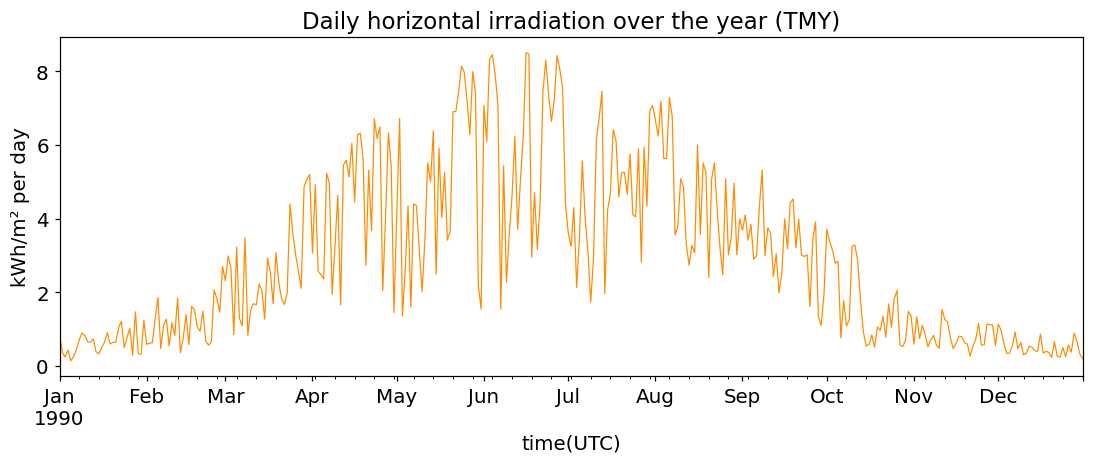

Best day:  8.5 kWh/m²
Worst day: 0.14 kWh/m²
Summer/winter ratio (Jun vs Dec, monthly): 11.6x


In [39]:
# Typical Meteorological Year: hourly data representing an average year,
# assembled by PVGIS from ~2005-2023 satellite-derived records
weather, meta = pvlib.iotools.get_pvgis_tmy(LAT, LON, map_variables=True)

print("Rows:", len(weather), "(hours in a year)")
weather.head(3)

# Daily energy: sum the 24 hourly values of each day -> kWh/m² per day
daily = weather["ghi"].resample("D").sum() / 1000

daily.plot(figsize=(12, 4), color="darkorange", linewidth=0.8)
plt.ylabel("kWh/m² per day")
plt.title("Daily horizontal irradiation over the year (TMY)")
plt.show()

print(f"Best day:  {daily.max():.1f} kWh/m²")
print(f"Worst day: {daily.min():.2f} kWh/m²")
print(f"Summer/winter ratio (Jun vs Dec, monthly): "
      f"{daily['1990-06'].sum() / daily['1990-12'].sum():.1f}x")


### Simulation model (per configuration)
1. **Solar position** hourly (pvlib; validated against Univ. of Oregon
   SRML sun path chart for Lat 53/Lon 8).
2. **Transposition** GHI/DNI/DHI → plane-of-array irradiance for given
   tilt/azimuth (isotropic sky model; Liu & Jordan 1963). Tilt and azimuth
   enter the model here only.
3. **Cell temperature** via Faiman (2008) from POA irradiance, air
   temperature, wind speed.
4. **DC power** via PVWatts (Dobos 2014, NREL/TP-6A20-62641):
   P = P_rated · (POA/1000) · [1 + γ(T_cell − 25°C)], with γ = −0.4%/K
   (generic mono-Si datasheet value; modern TOPCon ~−0.30 → our estimate
   is conservative; sensitivity: γ −0.3 changes annual yield by +0.2%).
5. **AC power** = DC × 0.90 (system losses: soiling, wiring, mismatch,
   LID — PVWatts default is 14% incl. 3% shading; we model shading
   explicitly via geometry, hence 10%) × 0.96 (inverter, PVWatts nominal).

**Key assumption:** unshaded planes (row shading handled via GCR spacing;
wing shading argued geometrically — NW-adjacent Staffelgeschoss blocks
only low-value evening sun).

**Baseline result (validation):** South 35°, 13.5 kWp → 13,784 kWh/a,
**1,021 kWh/kWp** — within the expected 900–1000+ corridor for an
unshaded south system in NW Germany ✓

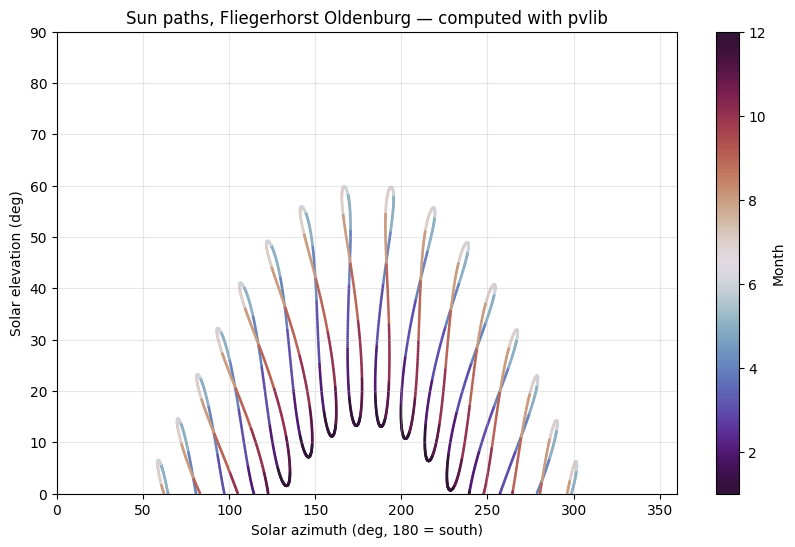

In [ ]:
#3 Model
import numpy as np

# Solar position for every hour of the TMY year
solpos = pvlib.solarposition.get_solarposition(weather.index, LAT, LON)
up = solpos["apparent_elevation"] > 0   # daylight hours only

plt.figure(figsize=(10, 6))
plt.scatter(solpos.loc[up, "azimuth"],
            solpos.loc[up, "apparent_elevation"],
            s=1, c=solpos.loc[up].index.month, cmap="twilight_shifted")
plt.colorbar(label="Month")
plt.xlabel("Solar azimuth (deg, 180 = south)")
plt.ylabel("Solar elevation (deg)")
plt.title("Sun paths, Fliegerhorst Oldenburg — computed with pvlib")
plt.xlim(0, 360); plt.ylim(0, 90)
plt.grid(alpha=0.3)
plt.show()

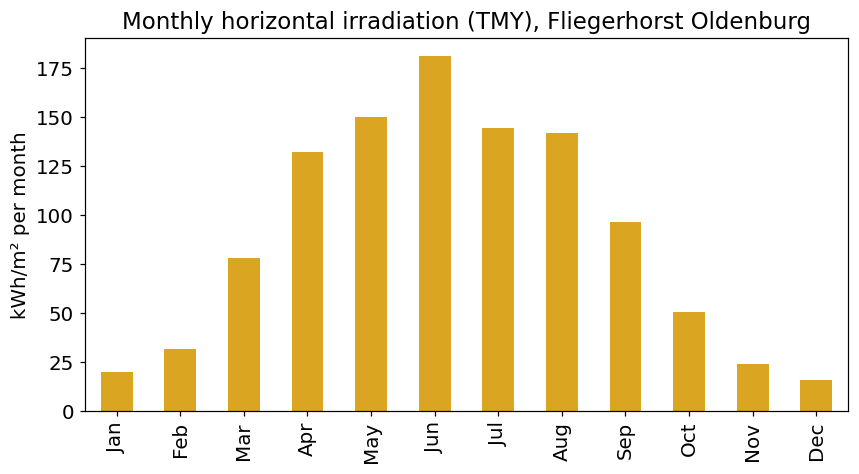

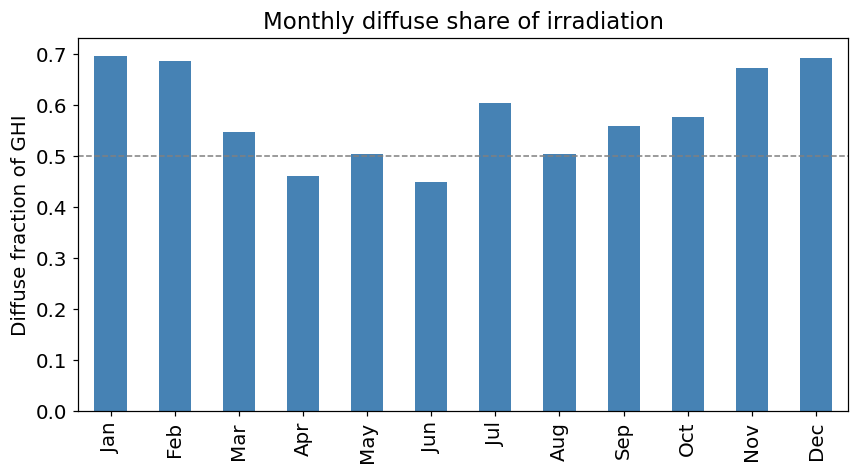

Annual diffuse share: 53%


In [40]:
# --- Figure 1: monthly GHI bars ---
monthly_ghi = weather["ghi"].resample("ME").sum() / 1000
monthly_ghi.index = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(8, 4.5))
monthly_ghi.plot.bar(color="goldenrod")
plt.ylabel("kWh/m² per month")
plt.title("Monthly horizontal irradiation (TMY), Fliegerhorst Oldenburg")
plt.tight_layout()
plt.savefig("fig_monthly_ghi.png", dpi=200)
plt.show()

# --- Figure 2: monthly diffuse share ---
diff_share = (weather["dhi"].resample("ME").sum()
              / weather["ghi"].resample("ME").sum())
diff_share.index = monthly_ghi.index
plt.figure(figsize=(8, 4.5))
diff_share.plot.bar(color="steelblue")
plt.axhline(0.5, color="gray", ls="--", lw=1)
plt.ylabel("Diffuse fraction of GHI")
plt.title("Monthly diffuse share of irradiation")
plt.tight_layout()
plt.savefig("fig_diffuse_share.png", dpi=200)
plt.show()

print("Annual diffuse share:",
      f"{weather['dhi'].sum()/weather['ghi'].sum():.0%}")

In [ ]:
# PV model: from sky to AC power

def simulate_pv(tilt, azimuth, kwp, weather, lat, lon):
    """Simulate hourly AC power (W) for one PV surface over the TMY year."""
    # 1) Where is the sun each hour?
    solpos = pvlib.solarposition.get_solarposition(weather.index, lat, lon)

    # 2) How much light lands on OUR tilted plane? (the transposition)
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt, surface_azimuth=azimuth,
        solar_zenith=solpos["apparent_zenith"],
        solar_azimuth=solpos["azimuth"],
        ghi=weather["ghi"], dni=weather["dni"], dhi=weather["dhi"])

    # 3) How hot do the cells get? (hot cells = less power)
    cell_temp = pvlib.temperature.faiman(
        poa["poa_global"], weather["temp_air"], weather["wind_speed"])

    # 4) DC power: proportional to light, corrected for temperature
    dc = pvlib.pvsystem.pvwatts_dc(
        poa["poa_global"], cell_temp,
        pdc0=kwp * 1000, gamma_pdc=-0.004)

    # 5) AC power: system losses (soiling, wiring, mismatch) + inverter
    return dc * 0.90 * 0.96


In [15]:
ac_south = simulate_pv(35, 180, KWP_SOUTH, weather, LAT, LON)

annual = ac_south.sum() / 1000
print(f"Annual yield:   {annual:,.0f} kWh")
print(f"Specific yield: {annual / KWP_SOUTH:,.0f} kWh/kWp")

Annual yield:   13,784 kWh
Specific yield: 1,021 kWh/kWp


# 4. Configuration study: all surfaces compared

In [16]:
# All configurations: name -> (tilt, azimuth, kWp or None)
CONFIGS = {
    "Roof South 35°": (35, 180, 13.5),
    "Roof E-W 10°":   None,               # special: two halves, see below
    "SE Wing 10°":    (10, 155, 6.5),
    "Facade WSW 90°": (90, 245, None),    # per-kWp comparison only
}

results = {}   # name -> hourly AC series (W)

# E-W = east half + west half, simulated separately and summed
ac_east = simulate_pv(10,  65, KWP_EW / 2, weather, LAT, LON)
ac_west = simulate_pv(10, 245, KWP_EW / 2, weather, LAT, LON)
results["Roof E-W 10°"] = ac_east + ac_west

results["Roof South 35°"] = simulate_pv(35, 180, 13.5, weather, LAT, LON)
results["SE Wing 10°"]    = simulate_pv(10, 155, 6.5,  weather, LAT, LON)
results["Facade WSW 90°"] = simulate_pv(90, 245, 1.0,  weather, LAT, LON)
# facade: 1 kWp -> its kWh ARE its kWh/kWp

kwp_map = {"Roof South 35°": 13.5, "Roof E-W 10°": 22.5,
           "SE Wing 10°": 6.5, "Facade WSW 90°": 1.0}

In [ ]:
rows = []
for name, ac in results.items():
    annual = ac.sum() / 1000                      # kWh
    kwp = kwp_map[name]
    monthly = ac.resample("ME").sum() / 1000
    rows.append({
        "Configuration": name,
        "kWp": kwp,
        "Annual kWh": round(annual),
        "kWh/kWp": round(annual / kwp),
        "Dec kWh/kWp": round(monthly.iloc[11] / kwp, 1),
        "Winter share %": round(monthly.iloc[[0,1,10,11]].sum()
                                 / annual * 100, 1),  # Nov-Feb
    })

comparison = pd.DataFrame(rows).set_index("Configuration")
comparison

,kWp,Annual kWh,kWh/kWp,Dec kWh/kWp,Winter share %
Configuration,,,,,
Roof E-W 10°,22.5,20497,911,14.6,9.3
Roof South 35°,13.5,13784,1021,25.6,12.8
SE Wing 10°,6.5,6290,968,18.1,10.3
Facade WSW 90°,1.0,658,658,15.4,13.0


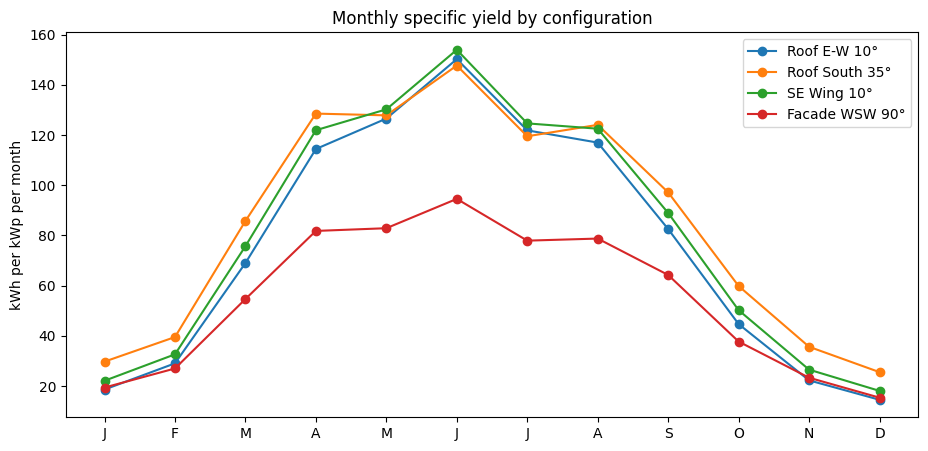

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, ac in results.items():
    monthly_per_kwp = ac.resample("ME").sum() / 1000 / kwp_map[name]
    ax.plot(range(1, 13), monthly_per_kwp.values, marker="o", label=name)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylabel("kWh per kWp per month")
ax.set_title("Monthly specific yield by configuration")
ax.legend()
plt.show()

# 5. Sensitivity: tilt and azimuth sweeps

 tilt sweep (south-facing, annual vs. December optimum)

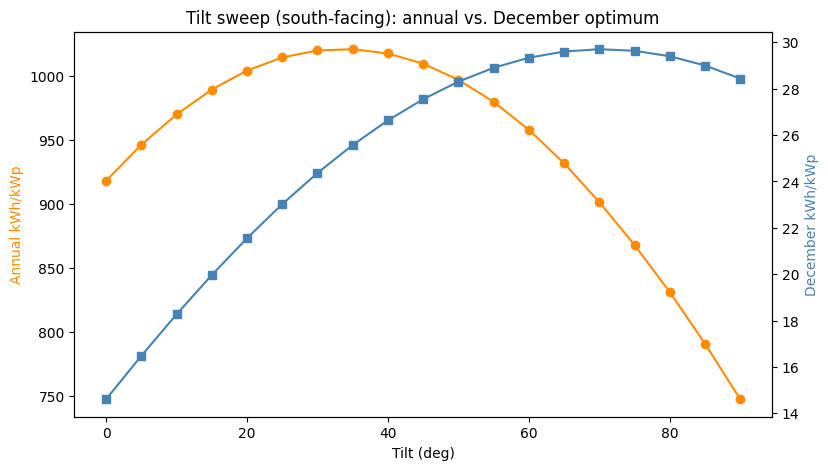

Annual optimum tilt:   35 deg
December optimum tilt: 70 deg


In [21]:
tilts = range(0, 91, 5)
annual_y, dec_y = [], []
for t in tilts:
    ac = simulate_pv(t, 180, 1.0, weather, LAT, LON)   # 1 kWp -> per-kWp
    annual_y.append(ac.sum() / 1000)
    dec_y.append(ac.loc["1990-12"].sum() / 1000)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(tilts, annual_y, "o-", color="darkorange", label="Annual")
ax1.set_xlabel("Tilt (deg)"); ax1.set_ylabel("Annual kWh/kWp", color="darkorange")
ax2 = ax1.twinx()
ax2.plot(tilts, dec_y, "s-", color="steelblue", label="December")
ax2.set_ylabel("December kWh/kWp", color="steelblue")
plt.title("Tilt sweep (south-facing): annual vs. December optimum")
plt.show()

print("Annual optimum tilt:  ", tilts[annual_y.index(max(annual_y))], "deg")
print("December optimum tilt:", tilts[dec_y.index(max(dec_y))], "deg")

azimuth sweep (at 35° tilt)

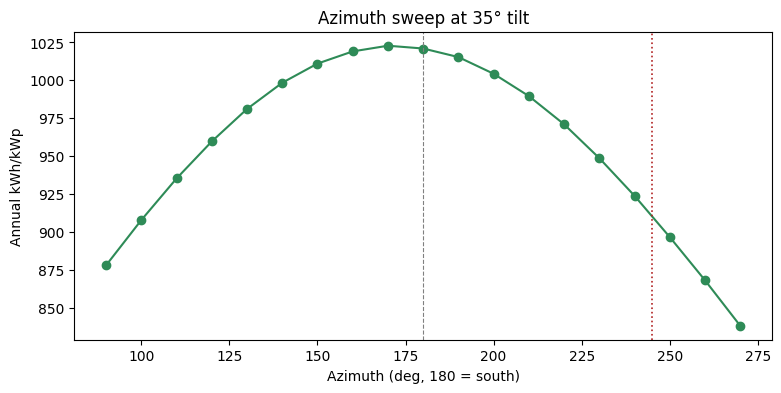

In [22]:
azis = range(90, 271, 10)
azi_y = [simulate_pv(35, a, 1.0, weather, LAT, LON).sum() / 1000 for a in azis]

plt.figure(figsize=(9, 4))
plt.plot(azis, azi_y, "o-", color="seagreen")
plt.axvline(180, color="gray", ls="--", lw=0.8)
plt.axvline(245, color="firebrick", ls=":", lw=1.2)   # your facade azimuth
plt.xlabel("Azimuth (deg, 180 = south)")
plt.ylabel("Annual kWh/kWp")
plt.title("Azimuth sweep at 35° tilt")
plt.show()

In [23]:
# Decision matrix: which configuration wins under which criterion?
criteria = pd.DataFrame({
    "Max annual kWh":        ["E-W (20,497)", ""],
    "Max kWh per kWp":       ["South (1,021)", ""],
    "Max December kWh/kWp":  ["South 35° (25.6); steeper would help", ""],
    "Most balanced seasons": ["Facade (13.0% winter share)", ""],
    "§32a coverage":         ["E-W (~51% by module area)", ""],
    "Self-consumption fit":  ["E-W (morning/evening spread)", ""],
}, index=["Winner", "Note"]).T
criteria

,Winner,Note
Max annual kWh,"E-W (20,497)",
Max kWh per kWp,"South (1,021)",
Max December kWh/kWp,South 35° (25.6); steeper would help,
Most balanced seasons,Facade (13.0% winter share),
§32a coverage,E-W (~51% by module area),
Self-consumption fit,E-W (morning/evening spread),


# 6. Design scenarios for this building

In [25]:
# ---- Section 6: Design scenarios for THIS building ----
scenarios = {
    # your proposal: E-W roof + south-tilted rows on the wing
    "A: Roof E-W + Wing South 35°": [
        (10,  65, 22.5/2), (10, 245, 22.5/2),   # roof E-W halves
        (35, 180, 3.9),                          # wing: south rows, GCR 45%
    ],
    # alternative: dense low-tilt everywhere, wing follows building axis
    "B: Roof E-W + Wing 155° 10°": [
        (10,  65, 22.5/2), (10, 245, 22.5/2),
        (10, 155, 6.5),                          # wing: dense, GCR 75%
    ],
    # curiosity: wing tilted steep for December hunting
    "C: Roof E-W + Wing South 65°": [
        (10,  65, 22.5/2), (10, 245, 22.5/2),
        (65, 180, 3.4),                          # steeper rows -> GCR ~38%
    ],
}

for name, arrays in scenarios.items():
    total = sum(simulate_pv(t, a, k, weather, LAT, LON)
                for t, a, k in arrays)
    kwp = sum(k for _, _, k in arrays)
    annual = total.sum() / 1000
    dec = total.loc["1990-12"].sum() / 1000
    print(f"{name}:  {kwp:.1f} kWp | "
          f"annual {annual:,.0f} kWh | December {dec:.0f} kWh")

A: Roof E-W + Wing South 35°:  26.4 kWp | annual 24,479 kWh | December 427 kWh
B: Roof E-W + Wing 155° 10°:  29.0 kWp | annual 26,787 kWh | December 445 kWh
C: Roof E-W + Wing South 65°:  25.9 kWp | annual 23,666 kWh | December 428 kWh


In [26]:
# True E-W (90/270), with ~7% packing loss from diagonal placement
ac_true = (simulate_pv(10,  90, 21.0/2, weather, LAT, LON)
         + simulate_pv(10, 270, 21.0/2, weather, LAT, LON))

# Building-aligned (57/237), full packing
ac_bldg = (simulate_pv(10,  57, 22.5/2, weather, LAT, LON)
         + simulate_pv(10, 237, 22.5/2, weather, LAT, LON))

for name, ac, kwp in [("True E-W 90/270 (21.0 kWp)", ac_true, 21.0),
                      ("Building-aligned 57/237 (22.5 kWp)", ac_bldg, 22.5)]:
    a = ac.sum()/1000
    print(f"{name}: {a:,.0f} kWh/a | {a/kwp:,.0f} kWh/kWp | "
          f"Dec {ac.loc['1990-12'].sum()/1000:.0f} kWh")

True E-W 90/270 (21.0 kWp): 19,134 kWh/a | 911 kWh/kWp | Dec 307 kWh
Building-aligned 57/237 (22.5 kWp): 20,495 kWh/a | 911 kWh/kWp | Dec 327 kWh


In [31]:
season = pd.Series([1.10,1.05,1.03,0.98,0.94,0.90,
                    0.90,0.92,0.96,1.02,1.08,1.12], index=monthly_B.index)
demand_m = 38000/12 * season          # kWh per month, seasonal
coverage = (monthly_B / demand_m * 100).round(0)

In [32]:
# Absolute monthly production of the recommended design (Scenario B)
ac_B = (simulate_pv(10,  57, 22.5/2, weather, LAT, LON)
      + simulate_pv(10, 237, 22.5/2, weather, LAT, LON)
      + simulate_pv(10, 147, 6.5,   weather, LAT, LON))

monthly_B = (ac_B.resample("ME").sum() / 1000).round(0)
monthly_B.index = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]

# household demand ~38,000 kWh/a spread by a rough seasonal profile
demand = 38000 / 12   # flat approximation; note the simplification
table = pd.DataFrame({"Production kWh": monthly_B,
                      "≈ Coverage of demand": (monthly_B/demand*100)
                                              .round(0).astype(int)
                                              .astype(str) + " %"})
print(table)
print(f"\nBest month:  {monthly_B.idxmax()} ({monthly_B.max():.0f} kWh)")
print(f"Worst month: {monthly_B.idxmin()} ({monthly_B.min():.0f} kWh)")

     Production kWh ≈ Coverage of demand
Jan           562.0                 18 %
Feb           864.0                 27 %
Mar          2042.0                 64 %
Apr          3365.0                106 %
May          3693.0                117 %
Jun          4381.0                138 %
Jul          3552.0                112 %
Aug          3427.0                108 %
Sep          2433.0                 77 %
Oct          1330.0                 42 %
Nov           672.0                 21 %
Dec           444.0                 14 %

Best month:  Jun (4381 kWh)
Worst month: Dec (444 kWh)


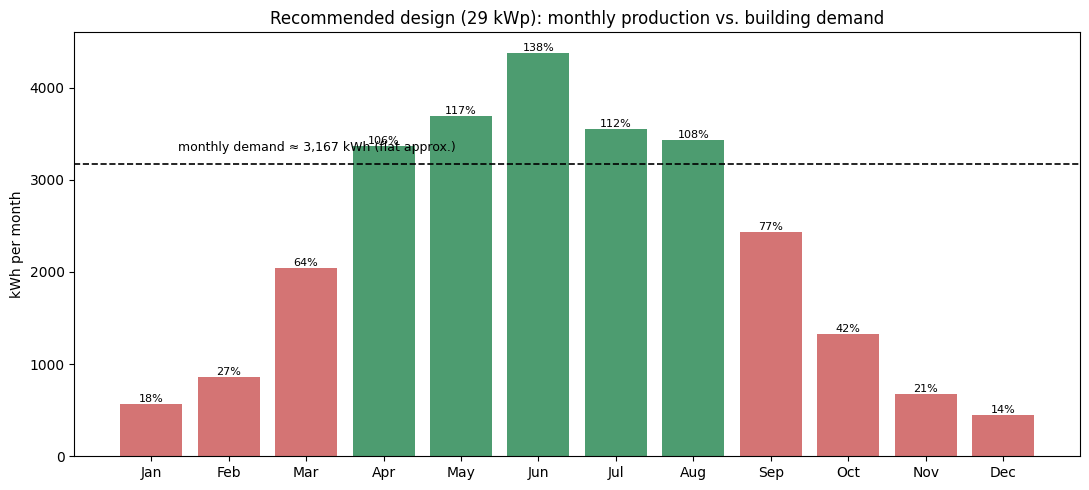

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))

months = monthly_B.index
colors = ["seagreen" if v >= demand else "indianred" for v in monthly_B]
ax.bar(months, monthly_B, color=colors, alpha=0.85)

# demand reference line
ax.axhline(demand, color="black", ls="--", lw=1.2)
ax.annotate(f"monthly demand ≈ {demand:,.0f} kWh (flat approx.)",
            xy=(0.35, demand), xytext=(0.35, demand + 150), fontsize=9)

# coverage % on top of each bar
for i, v in enumerate(monthly_B):
    ax.annotate(f"{v/demand*100:.0f}%", (i, v), ha="center",
                va="bottom", fontsize=8)

ax.set_ylabel("kWh per month")
ax.set_title("Recommended design (29 kWp): monthly production vs. building demand")
plt.tight_layout()
plt.show()

## 7.2 Monthly production vs. building demand (recommended design)

Absolute monthly output of Scenario B (29 kWp: roof E-W 57°/237° + wing 147°,
all 10° tilt) against estimated household electricity demand.

**Demand model:** 14 units × ~2,700 kWh/a (apartment households, cf.
Stromspiegel/BDEW) ≈ 38,000 kWh/a, distributed with monthly seasonal
weights (±~12%, winter-heavy, after German household statistics).
Household electricity only — heating (e.g. heat pump) excluded; an
electrified heating system would deepen the winter deficit substantially.

In [33]:
# ---------- 7.2 Monthly production vs. demand ----------

# Recommended design (Scenario B): building-aligned dense low-tilt
ac_B = (simulate_pv(10,  57, 22.5/2, weather, LAT, LON)   # roof, east half
      + simulate_pv(10, 237, 22.5/2, weather, LAT, LON)   # roof, west half
      + simulate_pv(10, 147, 6.5,   weather, LAT, LON))   # SE wing

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

# Production per month (kWh)
prod = ac_B.resample("ME").sum() / 1000
prod.index = MONTHS

# Demand: 38 MWh/a with seasonal weighting (winter-heavy household pattern)
ANNUAL_DEMAND = 38000   # kWh; 14 units x ~2,700 kWh (Stromspiegel/BDEW class)
season = pd.Series([1.10, 1.05, 1.03, 0.98, 0.94, 0.90,
                    0.90, 0.92, 0.96, 1.02, 1.08, 1.12], index=MONTHS)
season = season / season.mean()          # normalize: weights average to 1.0
demand_m = ANNUAL_DEMAND / 12 * season   # kWh per month

# Table
coverage = prod / demand_m * 100
table = pd.DataFrame({
    "Production kWh": prod.round(0),
    "Demand kWh":     demand_m.round(0),
    "Coverage %":     coverage.round(0).astype(int),
})
print(table)
print(f"\nAnnual production: {prod.sum():,.0f} kWh "
      f"({prod.sum()/ANNUAL_DEMAND*100:.0f} % of annual demand)")
print(f"Best month:  {prod.idxmax()} ({prod.max():.0f} kWh, "
      f"{coverage.max():.0f} % coverage)")
print(f"Worst month: {prod.idxmin()} ({prod.min():.0f} kWh, "
      f"{coverage.min():.0f} % coverage)")

     Production kWh  Demand kWh  Coverage %
Jan           562.0      3483.0          16
Feb           864.0      3325.0          26
Mar          2042.0      3262.0          63
Apr          3365.0      3103.0         108
May          3693.0      2977.0         124
Jun          4381.0      2850.0         154
Jul          3552.0      2850.0         125
Aug          3427.0      2913.0         118
Sep          2433.0      3040.0          80
Oct          1330.0      3230.0          41
Nov           672.0      3420.0          20
Dec           444.0      3547.0          13

Annual production: 26,765 kWh (70 % of annual demand)
Best month:  Jun (4381 kWh, 154 % coverage)
Worst month: Dec (444 kWh, 13 % coverage)


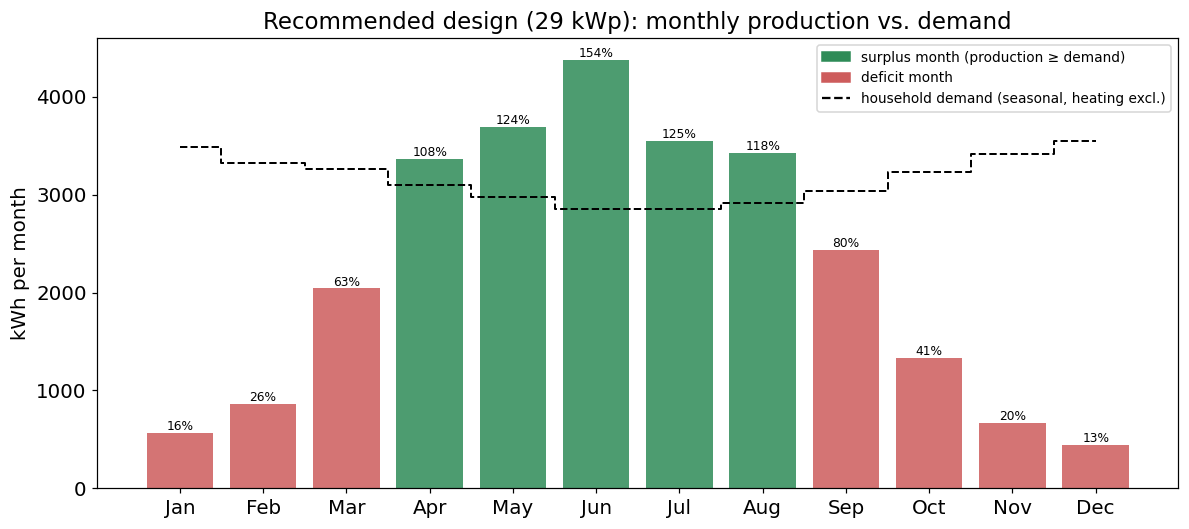

In [36]:
plt.rcParams.update({"font.size": 13, "axes.titlesize": 15,
                     "axes.labelsize": 13, "figure.dpi": 110})
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["seagreen" if p >= d else "indianred"
          for p, d in zip(prod, demand_m)]
ax.bar(MONTHS, prod, color=colors, alpha=0.85, label="PV production")

# seasonal demand as a step line
ax.step(range(12), demand_m, where="mid", color="black",
        ls="--", lw=1.3, label="household demand (seasonal, heating excl.)")

# coverage % above each bar
for i, (p, c) in enumerate(zip(prod, coverage)):
    ax.annotate(f"{c:.0f}%", (i, p), ha="center", va="bottom", fontsize=8)

ax.set_ylabel("kWh per month")
ax.set_title("Recommended design (29 kWp): monthly production vs. demand")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="seagreen", label="surplus month (production ≥ demand)"),
    Patch(color="indianred", label="deficit month"),
    plt.Line2D([0], [0], color="black", ls="--",
               label="household demand (seasonal, heating excl.)"),
], loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()